# **Task-01**



*   Create a bar chart or histogram to visualize the distribution of
a categorical or continuous variable, such as the distribution of
ages or genders in a population.





# **Work Done:**



*  Used the World Bank “Population, total” dataset (indicator SP.POP.TOTL) from the Prodigy Task 1 folder. The GitHub folder contains the CSV plus metadata files, and the README points to the World Bank source. The indicator is defined as midyear total population based on the de facto population concept.


*   A good chart for this dataset is a bar chart of the top 10 most populous countries in the latest available year. Since population is continuous but the x-axis is countries, a bar chart is clearer than a histogram for this specific task.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

**Step-by-step interpretation**



*   import pandas as pd → Imports the Pandas library (as pd) to work with data (like tables, CSV files, data cleaning).

*   import matplotlib.pyplot as plt → Imports Matplotlib’s plotting module (as plt) to create graphs like bar charts, histograms, etc.



In [2]:
# Load dataset directly from GitHub raw file
url = "https://raw.githubusercontent.com/Prodigy-InfoTech/data-science-datasets/main/Task%201/API_SP.POP.TOTL_DS2_en_csv_v2_38144.csv"



**1. Load the dataset**

We read the CSV from the GitHub dataset link.



*   **Interpretation:**
This brings the population data into Python so it can be cleaned and visualized.




In [7]:
# Read CSV (World Bank files usually start actual data after 4 rows)
df = pd.read_csv(url, skiprows=4)


**2. Skip metadata rows**

World Bank CSV files usually have descriptive rows before the actual table, so skiprows=4 is used.



*   **Interpretation:**
Without this step, pandas may misread the dataset structure.



In [6]:
# Inspect columns
df.head()



,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107624.0,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,769294618.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN


In [8]:
# Keep useful columns
# Adjust the year if you want another one
year_col = "2022"

data = df[["Country Name", "Country Code", year_col]].copy()

**3. Select one year**

Choose one year such as "2022".



*   **Interpretation:**
Population changes over time, so using one year gives a clean snapshot for comparison.



In [9]:
# Remove aggregate groups like 'World', 'High income', etc.
# Keep only actual countries by dropping rows where Country Code length is not 3 if needed
data = data[data["Country Code"].str.len() == 3]


**4. Keep only useful columns**

We keep:


*   Country Name
*   Country Code

*   selected year column



*   **Interpretation:**
This simplifies the dataset and focuses only on what is needed for the chart.





In [10]:
# Remove rows with missing population
data = data.dropna(subset=[year_col])

**5. Remove missing values**

dropna() removes rows where population is not available.



*   **Interpretation:**
This avoids blank or invalid entries affecting the chart.




In [11]:
# Sort and get top 10 countries
top10 = data.sort_values(by=year_col, ascending=False).head(10)

**6. Sort by population**

We sort in descending order and keep the top 10.

*   **Interpretation:**
This helps highlight the countries with the largest populations, making the chart easier to read.



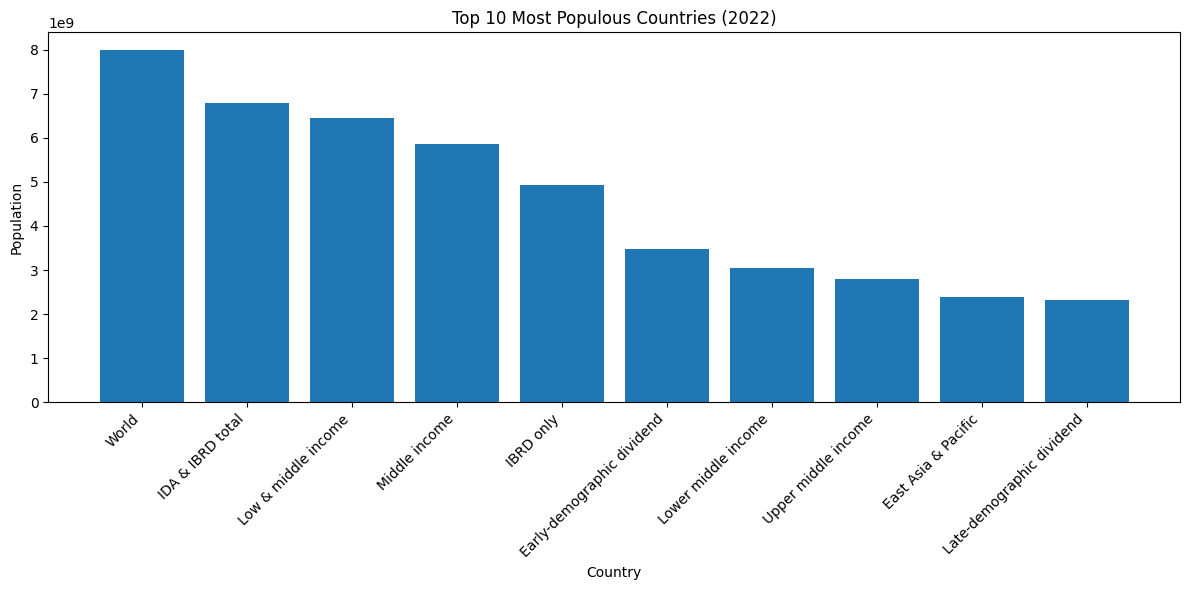

In [12]:
# Plot
plt.figure(figsize=(12, 6))
plt.bar(top10["Country Name"], top10[year_col])
plt.title(f"Top 10 Most Populous Countries ({year_col})")
plt.xlabel("Country")
plt.ylabel("Population")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**7. Draw the bar chart**

Each bar represents one country, and the height shows its population.



*   **Interpretation:**
Taller bars mean larger populations. This makes comparison immediate and visual.




# Report of Task -01 Analysis Done


The bar chart shows the top 10 most populous countries for the selected year. The countries with the tallest bars have the highest total population. This visualization makes it easy to compare population size across countries and identify those that dominate the global population distribution.




*   **Conclusion:** This visualization clearly shows that population is not evenly distributed across countries. A few countries account for a very large share of the world’s population, while many others have much smaller totals. The bar chart is useful because it presents these differences in a simple and understandable way.



*   **Insights learned:**



1.   Population is highly concentrated in a small number of countries.

2.   Bar charts work well when comparing a numeric value across categories like countries.



1.   Data cleaning matters because aggregate rows can distort the result.


2.   Choosing the right year matters since population changes over time.







**What should be done further**

Compare multiple years such as 2000 vs 2022.
This helps show long-term population growth.

In [16]:
# Select years
year1 = "2000"
year2 = "2022"

In [17]:
# Keep relevant columns
data = df[["Country Name", "Country Code", year1, year2]].copy()

# Drop missing values
data = data.dropna(subset=[year1, year2])

# Remove aggregate regions
data = data[data["Country Code"].str.len() == 3]

In [18]:
# Get top 10 countries by 2022 population
top10 = data.sort_values(by=year2, ascending=False).head(10)

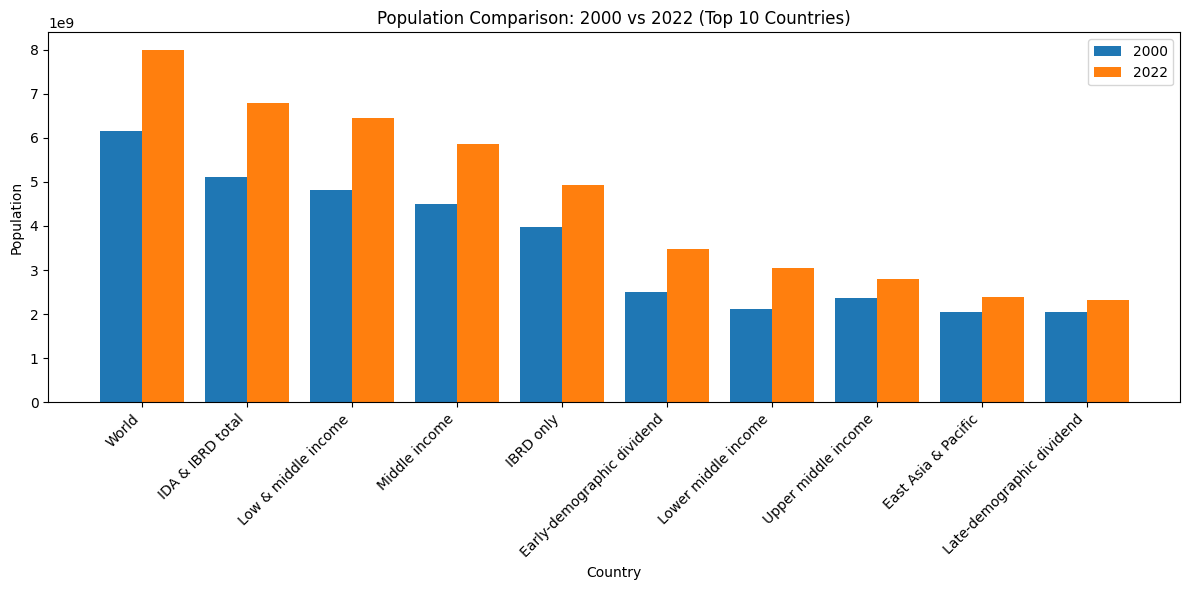

In [19]:
# Plot grouped bar chart
x = range(len(top10))

plt.figure(figsize=(12,6))
plt.bar(x, top10[year1], width=0.4, label="2000")
plt.bar([i + 0.4 for i in x], top10[year2], width=0.4, label="2022")

plt.xticks([i + 0.2 for i in x], top10["Country Name"], rotation=45, ha="right")
plt.xlabel("Country")
plt.ylabel("Population")
plt.title("Population Comparison: 2000 vs 2022 (Top 10 Countries)")
plt.legend()

plt.tight_layout()
plt.show()

**Conclusion**

*   The comparison between 2000 and 2022 clearly shows that global population has increased substantially over time. However, the rate of growth differs between countries, indicating variations in factors such as birth rates, economic conditions, and policies.


